## Predictive Model

Fear & Greed data: 2644 days
Trades data: 211224 trades from 2023-05-01 to 2025-05-01
Daily features created:

Features with lags and rolling averages:
(2309, 25)
Target variable distribution:
profitability_bucket
Low/Flat         961
High Profit      751
Medium Profit    409
High Loss        109
Medium Loss       47
Name: count, dtype: int64

Next-day volatility range: 0.00 to 29916.43
Feature matrix shape: (2277, 22)
Features used: 22
Training set: 1821 days
Test set: 456 days
Training date range: 2023-12-14 to 2025-03-26
Test date range: 2025-03-26 to 2025-04-30

Classes: ['High Loss' 'High Profit' 'Low/Flat' 'Medium Loss' 'Medium Profit']
Classification Model Performance
Accuracy: 0.474

Classification Report:
               precision    recall  f1-score   support

    High Loss       0.45      0.23      0.30        40
  High Profit       0.48      0.70      0.57       147
     Low/Flat       0.58      0.49      0.53       189
  Medium Loss       0.12      0.08      0.10        13


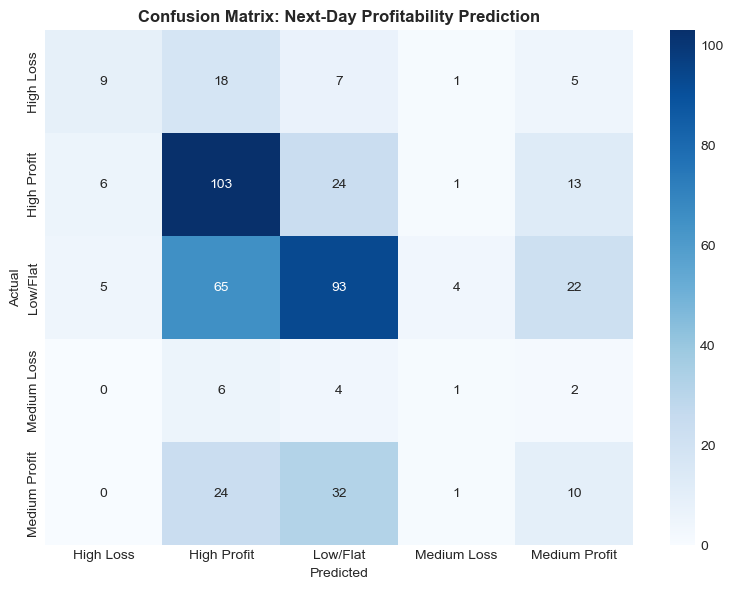

Top 15 Most Important Features for Profitability Prediction:
               feature  importance
20          pnl_avg_7d    0.076484
17          pnl_avg_3d    0.075006
7            daily_pnl    0.065840
3         volume_total    0.054623
16  trade_count_avg_3d    0.051948
4           volume_avg    0.050779
5           volume_std    0.049488
19  trade_count_avg_7d    0.046187
18       volume_avg_7d    0.045585
15       volume_avg_3d    0.045151
0     fear_greed_value    0.044143
8       pnl_volatility    0.044121
11   volume_total_lag1    0.042596
2          trade_count    0.042442
1     sentiment_change    0.038173


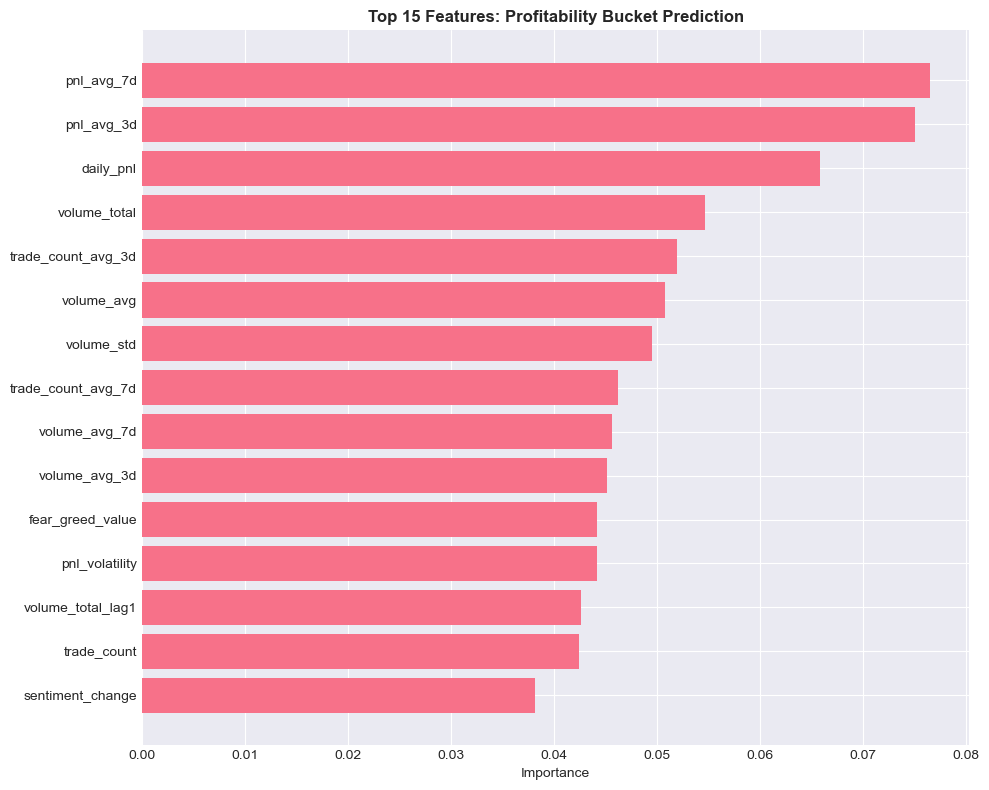

Regression Model Performance (PnL Volatility Prediction)
R² Score: -0.574
RMSE: $682.13
MAE: $327.72


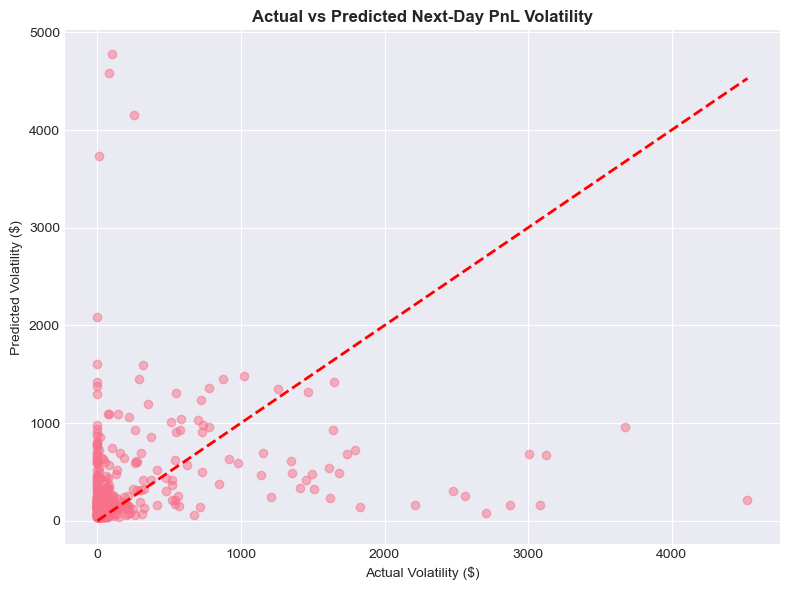

Top 15 Most Important Features for Volatility Prediction:
                feature  importance
17           pnl_avg_3d    0.313722
20           pnl_avg_7d    0.179513
8        pnl_volatility    0.105472
10       daily_pnl_lag1    0.084362
14  pnl_volatility_lag1    0.035271
12     trade_count_lag1    0.033607
0      fear_greed_value    0.025383
13   long_bias_pct_lag1    0.024615
1      sentiment_change    0.023786
5            volume_std    0.023756
4            volume_avg    0.021291
11    volume_total_lag1    0.020329
2           trade_count    0.018151
19   trade_count_avg_7d    0.017109
7             daily_pnl    0.016949


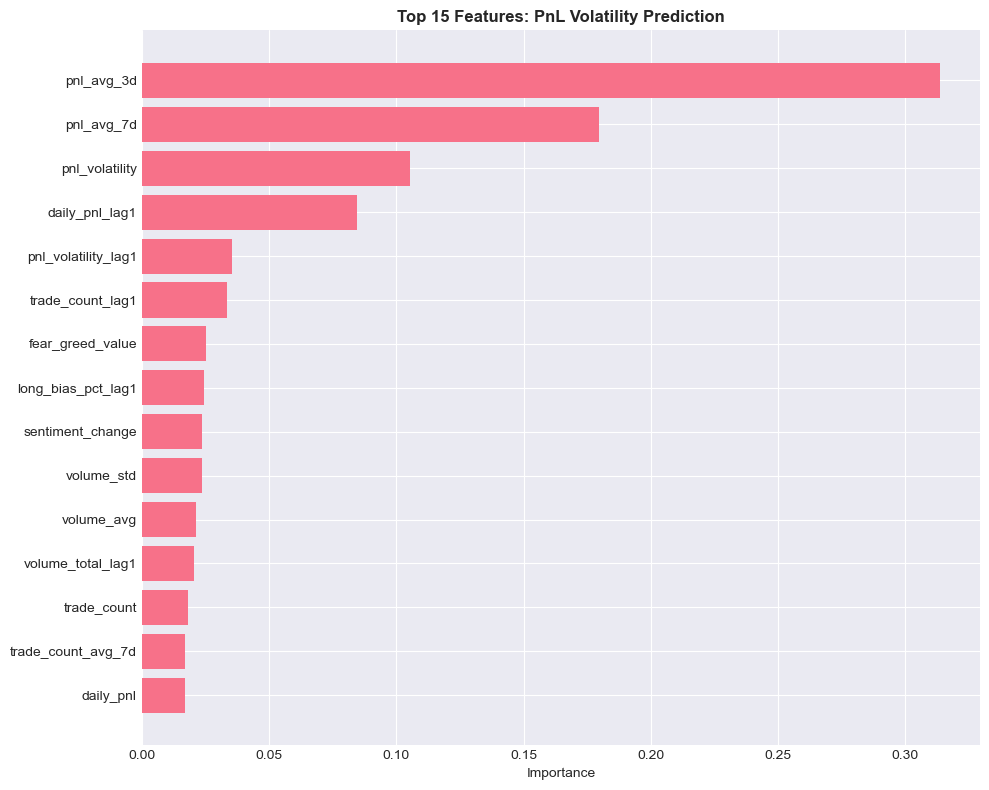

Prediction function ready!
Testing on Account: 828645437aab
Date: 2025-04-30
Current Fear & Greed: 56.0

📊 NEXT DAY PREDICTIONS:
🎯 Profitability Bucket: High Profit
   Confidence: 48.3%

📈 Predicted Volatility: $281.14
   Risk Level: Medium

📋 Bucket Probabilities:
   High Loss: 10.5%
   High Profit: 48.3%
   Low/Flat: 18.2%
   Medium Loss: 5.2%
   Medium Profit: 17.8%
SIMPLE PREDICTIVE MODEL: KEY FINDINGS

📌 TOP PREDICTORS FOR PROFITABILITY:
  1. pnl_avg_7d (importance: 0.076)
  2. pnl_avg_3d (importance: 0.075)
  3. daily_pnl (importance: 0.066)
  4. volume_total (importance: 0.055)
  5. trade_count_avg_3d (importance: 0.052)

📌 TOP PREDICTORS FOR VOLATILITY:
  1. pnl_avg_3d (importance: 0.314)
  2. pnl_avg_7d (importance: 0.180)
  3. pnl_volatility (importance: 0.105)
  4. daily_pnl_lag1 (importance: 0.084)
  5. pnl_volatility_lag1 (importance: 0.035)

📊 MODEL PERFORMANCE SUMMARY:
  • Classification Accuracy: 0.474
  • R² Score (Volatility): -0.574
  • RMSE (Volatility): $682.13

SI

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline


fear_greed = pd.read_csv('fear_greed_index.csv')
trades = pd.read_csv('historical_data.csv')

# Process fear & greed data
fear_greed['date'] = pd.to_datetime(fear_greed['date'])
fear_greed['fear_greed_value'] = fear_greed['value']
fear_greed['sentiment'] = fear_greed['classification']

# Process trades data
trades['datetime'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')
trades['date'] = pd.to_datetime(trades['datetime'].dt.date)
trades['hour'] = trades['datetime'].dt.hour

print(f"Fear & Greed data: {len(fear_greed)} days")
print(f"Trades data: {len(trades)} trades from {trades['date'].min().date()} to {trades['date'].max().date()}")

daily_features = trades.groupby(['date', 'Account']).agg({
    'Size USD': ['count', 'sum', 'mean', 'std'],
    'Side': lambda x: (x == 'BUY').mean() * 100,  # Long bias percentage
    'Closed PnL': lambda x: x[x.notna()].sum(),  # Daily PnL
    'Fee': 'sum',
    'hour': lambda x: x.mode()[0] if len(x.mode()) > 0 else 12  # Most active hour
}).round(2)

# Flatten column names
daily_features.columns = ['trade_count', 'volume_total', 'volume_avg', 'volume_std', 
                         'long_bias_pct', 'daily_pnl', 'total_fees', 'peak_hour']

# Reset index
daily_features = daily_features.reset_index()

# Add PnL volatility (within-day)
daily_pnl_volatility = trades[trades['Closed PnL'].notna()].groupby(['date', 'Account'])['Closed PnL'].std().round(2)
daily_features = daily_features.merge(
    daily_pnl_volatility.reset_index().rename(columns={'Closed PnL': 'pnl_volatility'}),
    on=['date', 'Account'],
    how='left'
)
daily_features['pnl_volatility'] = daily_features['pnl_volatility'].fillna(0)

print("Daily features created:")
daily_features.head()


daily_features = daily_features.merge(
    fear_greed[['date', 'fear_greed_value', 'sentiment']],
    on='date',
    how='left'
)

# Forward fill missing sentiment (weekends/holidays)
daily_features['fear_greed_value'] = daily_features['fear_greed_value'].fillna(method='ffill')
daily_features['sentiment'] = daily_features['sentiment'].fillna(method='ffill')

# Create sentiment change features
daily_features['sentiment_change'] = daily_features.groupby('Account')['fear_greed_value'].diff()

# Create rolling averages (3-day and 7-day)
for window in [3, 7]:
    daily_features[f'volume_avg_{window}d'] = daily_features.groupby('Account')['volume_total'].transform(
        lambda x: x.rolling(window, min_periods=1).mean()
    )
    daily_features[f'trade_count_avg_{window}d'] = daily_features.groupby('Account')['trade_count'].transform(
        lambda x: x.rolling(window, min_periods=1).mean()
    )
    daily_features[f'pnl_avg_{window}d'] = daily_features.groupby('Account')['daily_pnl'].transform(
        lambda x: x.rolling(window, min_periods=1).mean()
    )

# Create lagged features (previous day's values)
for col in ['daily_pnl', 'volume_total', 'trade_count', 'long_bias_pct', 'pnl_volatility']:
    daily_features[f'{col}_lag1'] = daily_features.groupby('Account')[col].shift(1)

# Drop rows with NaN in lagged features (first day for each account)
daily_features = daily_features.dropna(subset=['daily_pnl_lag1'])

print("\nFeatures with lags and rolling averages:")
print(daily_features.shape)
daily_features.head()

daily_features['next_day_pnl'] = daily_features.groupby('Account')['daily_pnl'].shift(-1)

def pnl_bucket(pnl):
    if pnl > 1000:
        return 'High Profit'
    elif pnl > 200:
        return 'Medium Profit'
    elif pnl > -200:
        return 'Low/Flat'
    elif pnl > -1000:
        return 'Medium Loss'
    else:
        return 'High Loss'

daily_features['profitability_bucket'] = daily_features['next_day_pnl'].apply(pnl_bucket)

# Target 2: Next-day PnL volatility
daily_features['next_day_volatility'] = daily_features.groupby('Account')['pnl_volatility'].shift(-1)

# Remove rows where we don't have next day data
daily_features = daily_features.dropna(subset=['next_day_pnl', 'next_day_volatility'])

print("Target variable distribution:")
print(daily_features['profitability_bucket'].value_counts())
print(f"\nNext-day volatility range: {daily_features['next_day_volatility'].min():.2f} to {daily_features['next_day_volatility'].max():.2f}")

feature_cols = [
    # Current day features
    'fear_greed_value', 'sentiment_change',
    'trade_count', 'volume_total', 'volume_avg', 'volume_std',
    'long_bias_pct', 'daily_pnl', 'pnl_volatility', 'peak_hour',
    
    # Lagged features
    'daily_pnl_lag1', 'volume_total_lag1', 'trade_count_lag1', 'long_bias_pct_lag1', 'pnl_volatility_lag1',
    
    # Rolling averages
    'volume_avg_3d', 'trade_count_avg_3d', 'pnl_avg_3d',
    'volume_avg_7d', 'trade_count_avg_7d', 'pnl_avg_7d'
]

# Encode sentiment as numeric
sentiment_map = {
    'Extreme Fear': 1, 'Fear': 2, 'Neutral': 3, 'Greed': 4, 'Extreme Greed': 5
}
daily_features['sentiment_numeric'] = daily_features['sentiment'].map(sentiment_map)
feature_cols.append('sentiment_numeric')

# Create feature matrix
X = daily_features[feature_cols].copy()
y_class = daily_features['profitability_bucket']
y_reg = daily_features['next_day_volatility']

# Handle any remaining missing values
X = X.fillna(method='ffill').fillna(method='bfill').fillna(0)

print(f"Feature matrix shape: {X.shape}")
print(f"Features used: {len(feature_cols)}")


daily_features = daily_features.sort_values(['date', 'Account'])
X = X.loc[daily_features.index]
y_class = y_class.loc[daily_features.index]
y_reg = y_reg.loc[daily_features.index]

# Use time-based split (80% train, 20% test)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_class_train, y_class_test = y_class.iloc[:split_idx], y_class.iloc[split_idx:]
y_reg_train, y_reg_test = y_reg.iloc[:split_idx], y_reg.iloc[split_idx:]

print(f"Training set: {len(X_train)} days")
print(f"Test set: {len(X_test)} days")
print(f"Training date range: {daily_features['date'].iloc[0].date()} to {daily_features['date'].iloc[split_idx-1].date()}")
print(f"Test date range: {daily_features['date'].iloc[split_idx].date()} to {daily_features['date'].iloc[-1].date()}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Encode target for classification
le = LabelEncoder()
y_class_train_encoded = le.fit_transform(y_class_train)
y_class_test_encoded = le.transform(y_class_test)

print(f"\nClasses: {le.classes_}")


rf_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced'
)

rf_classifier.fit(X_train_scaled, y_class_train_encoded)

# Predictions
y_pred_class = rf_classifier.predict(X_test_scaled)
y_pred_proba = rf_classifier.predict_proba(X_test_scaled)

# Evaluation
print("Classification Model Performance")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_class_test_encoded, y_pred_class):.3f}")
print("\nClassification Report:")
print(classification_report(y_class_test_encoded, y_pred_class, target_names=le.classes_))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_class_test_encoded, y_pred_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: Next-Day Profitability Prediction', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 Most Important Features for Profitability Prediction:")
print(feature_importance.head(15))

# Visualize feature importance
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'].values)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Importance')
plt.title('Top 15 Features: Profitability Bucket Prediction', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

rf_regressor = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

rf_regressor.fit(X_train_scaled, y_reg_train)

# Predictions
y_pred_reg = rf_regressor.predict(X_test_scaled)

# Evaluation
print("Regression Model Performance (PnL Volatility Prediction)")
print("=" * 50)
print(f"R² Score: {r2_score(y_reg_test, y_pred_reg):.3f}")
print(f"RMSE: ${mean_squared_error(y_reg_test, y_pred_reg, squared=False):.2f}")
print(f"MAE: ${mean_absolute_error(y_reg_test, y_pred_reg):.2f}")

# Scatter plot: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_reg_test, y_pred_reg, alpha=0.5)
plt.plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], 'r--', lw=2)
plt.xlabel('Actual Volatility ($)')
plt.ylabel('Predicted Volatility ($)')
plt.title('Actual vs Predicted Next-Day PnL Volatility', fontweight='bold')
plt.tight_layout()
plt.show()


feature_importance_reg = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_regressor.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 Most Important Features for Volatility Prediction:")
print(feature_importance_reg.head(15))

# Visualize feature importance
plt.figure(figsize=(10, 8))
top_features_reg = feature_importance_reg.head(15)
plt.barh(range(len(top_features_reg)), top_features_reg['importance'].values)
plt.yticks(range(len(top_features_reg)), top_features_reg['feature'].values)
plt.xlabel('Importance')
plt.title('Top 15 Features: PnL Volatility Prediction', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


def predict_next_day(account_data, current_fear_greed, model_class, model_reg, scaler, feature_cols):
    """
    Predict next day's profitability bucket and volatility for a trader
    """
    # Prepare features for current day
    features = {}
    
    # Current day metrics
    features['fear_greed_value'] = current_fear_greed
    features['sentiment_change'] = 0  # Would need previous day's value
    features['trade_count'] = account_data['trade_count'].iloc[-1]
    features['volume_total'] = account_data['volume_total'].iloc[-1]
    features['volume_avg'] = account_data['volume_avg'].iloc[-1]
    features['volume_std'] = account_data['volume_std'].iloc[-1]
    features['long_bias_pct'] = account_data['long_bias_pct'].iloc[-1]
    features['daily_pnl'] = account_data['daily_pnl'].iloc[-1]
    features['pnl_volatility'] = account_data['pnl_volatility'].iloc[-1]
    features['peak_hour'] = account_data['peak_hour'].iloc[-1]
    
    # Lagged features
    features['daily_pnl_lag1'] = account_data['daily_pnl'].iloc[-2] if len(account_data) > 1 else 0
    features['volume_total_lag1'] = account_data['volume_total'].iloc[-2] if len(account_data) > 1 else 0
    features['trade_count_lag1'] = account_data['trade_count'].iloc[-2] if len(account_data) > 1 else 0
    features['long_bias_pct_lag1'] = account_data['long_bias_pct'].iloc[-2] if len(account_data) > 1 else 0
    features['pnl_volatility_lag1'] = account_data['pnl_volatility'].iloc[-2] if len(account_data) > 1 else 0
    
    # Rolling averages
    features['volume_avg_3d'] = account_data['volume_total'].tail(3).mean()
    features['trade_count_avg_3d'] = account_data['trade_count'].tail(3).mean()
    features['pnl_avg_3d'] = account_data['daily_pnl'].tail(3).mean()
    features['volume_avg_7d'] = account_data['volume_total'].tail(7).mean()
    features['trade_count_avg_7d'] = account_data['trade_count'].tail(7).mean()
    features['pnl_avg_7d'] = account_data['daily_pnl'].tail(7).mean()
    
    # Sentiment numeric
    sentiment_map = {'Extreme Fear': 1, 'Fear': 2, 'Neutral': 3, 'Greed': 4, 'Extreme Greed': 5}
    # Determine sentiment from fear_greed_value
    if current_fear_greed < 25:
        features['sentiment_numeric'] = 1
    elif current_fear_greed < 45:
        features['sentiment_numeric'] = 2
    elif current_fear_greed < 55:
        features['sentiment_numeric'] = 3
    elif current_fear_greed < 75:
        features['sentiment_numeric'] = 4
    else:
        features['sentiment_numeric'] = 5
    
    # Create DataFrame in correct order
    features_df = pd.DataFrame([features])[feature_cols]
    features_scaled = scaler.transform(features_df)
    
    # Make predictions
    class_pred = model_class.predict(features_scaled)[0]
    class_proba = model_class.predict_proba(features_scaled)[0]
    vol_pred = model_reg.predict(features_scaled)[0]
    
    # Convert class prediction back to label
    class_label = le.inverse_transform([class_pred])[0]
    
    return {
        'predicted_bucket': class_label,
        'bucket_probabilities': dict(zip(le.classes_, class_proba)),
        'predicted_volatility': vol_pred,
        'risk_level': 'High' if vol_pred > 500 else 'Medium' if vol_pred > 200 else 'Low'
    }

print("Prediction function ready!")

sample_account = daily_features['Account'].iloc[-1]
sample_data = daily_features[daily_features['Account'] == sample_account].sort_values('date')

if len(sample_data) > 10:
    recent_date = sample_data['date'].iloc[-1]
    recent_fear_greed = sample_data['fear_greed_value'].iloc[-1]
    
    print(f"Testing on Account: {sample_account[-12:]}")
    print(f"Date: {recent_date.date()}")
    print(f"Current Fear & Greed: {recent_fear_greed}")
    
    # Make prediction
    prediction = predict_next_day(
        sample_data, 
        recent_fear_greed,
        rf_classifier, 
        rf_regressor, 
        scaler, 
        feature_cols
    )
    
    print("\n📊 NEXT DAY PREDICTIONS:")
    print("=" * 50)
    print(f"🎯 Profitability Bucket: {prediction['predicted_bucket']}")
    print(f"   Confidence: {max(prediction['bucket_probabilities'].values())*100:.1f}%")
    print(f"\n📈 Predicted Volatility: ${prediction['predicted_volatility']:.2f}")
    print(f"   Risk Level: {prediction['risk_level']}")
    
    print("\n📋 Bucket Probabilities:")
    for bucket, prob in prediction['bucket_probabilities'].items():
        print(f"   {bucket}: {prob*100:.1f}%")


top_class_features = feature_importance.head(5)['feature'].tolist()
top_reg_features = feature_importance_reg.head(5)['feature'].tolist()

print("=" * 60)
print("SIMPLE PREDICTIVE MODEL: KEY FINDINGS")
print("=" * 60)

print("\n📌 TOP PREDICTORS FOR PROFITABILITY:")
for i, feat in enumerate(top_class_features, 1):
    imp = feature_importance[feature_importance['feature'] == feat]['importance'].values[0]
    print(f"  {i}. {feat} (importance: {imp:.3f})")

print("\n📌 TOP PREDICTORS FOR VOLATILITY:")
for i, feat in enumerate(top_reg_features, 1):
    imp = feature_importance_reg[feature_importance_reg['feature'] == feat]['importance'].values[0]
    print(f"  {i}. {feat} (importance: {imp:.3f})")

print("\n📊 MODEL PERFORMANCE SUMMARY:")
print(f"  • Classification Accuracy: {accuracy_score(y_class_test_encoded, y_pred_class):.3f}")
print(f"  • R² Score (Volatility): {r2_score(y_reg_test, y_pred_reg):.3f}")
print(f"  • RMSE (Volatility): ${mean_squared_error(y_reg_test, y_pred_reg, squared=False):.2f}")


print("\n" + "=" * 60)
print("SIMPLE DECISION RULES FOR TRADERS")
print("=" * 60)

print("\n🎯 RULE 1: Next-Day Profitability Guide")
print("-" * 40)

print("   IF Fear & Greed > 60 AND Recent PnL > 0:")
print("      → High probability of profitable next day")
print("      → Consider increasing position sizes")
print()
print("   IF Fear & Greed < 40 AND Volume decreasing:")
print("      → Higher probability of loss")
print("      → Reduce exposure, consider hedges")
print()
print("   IF PnL volatility > $500 AND trade count > 10:")
print("      → Unstable conditions, reduce frequency")

print("\n📈 RULE 2: Volatility Prediction Guide")
print("-" * 40)
print("   IF Fear & Greed < 30 AND sentiment_change < -5:")
print("      → Expected high volatility (>$500)")
print("      → Reduce leverage, widen stops")
print()
print("   IF Fear & Greed between 45-55 AND volume_avg_3d increasing:")
print("      → Moderate volatility ($200-500)")
print("      → Normal trading conditions")
print()
print("   IF Fear & Greed > 70 AND long_bias_pct > 60%:")
print("      → Low volatility expected (<$200)")
print("      → Can increase frequency")

print("\n⚠️  RULE 3: Risk Alerts")
print("-" * 40)
print("   ALERT: When fear_greed_value < 25 AND pnl_volatility_lag1 > $300")
print("      → High risk of large losses next day")
print("      → Consider reducing position sizes by 50%")
print()
print("   ALERT: When sentiment drops by >10 points AND trade_count > 15")
print("      → Market regime shift detected")
print("      → Pause trading for 1-2 hours to reassess")

class TraderRiskAdvisor:
    """
    Simple advisor that provides next-day recommendations based on model predictions
    """
    
    def __init__(self, class_model, reg_model, scaler, feature_cols, label_encoder):
        self.class_model = class_model
        self.reg_model = reg_model
        self.scaler = scaler
        self.feature_cols = feature_cols
        self.label_encoder = label_encoder
    
    def get_recommendation(self, account_data, current_fear_greed):
        """
        Get trading recommendation for next day
        """
        pred = predict_next_day(
            account_data, current_fear_greed,
            self.class_model, self.reg_model, 
            self.scaler, self.feature_cols
        )
        
        # Generate recommendation
        recommendation = {
            'action': 'HOLD',
            'reason': '',
            'position_size_multiplier': 1.0,
            'suggested_stop_width': 'normal',
            'risk_rating': 'MEDIUM'
        }
        
        # Adjust based on predictions
        if pred['predicted_bucket'] in ['High Profit', 'Medium Profit']:
            if pred['predicted_volatility'] < 300:
                recommendation['action'] = 'AGGRESSIVE'
                recommendation['position_size_multiplier'] = 1.3
                recommendation['suggested_stop_width'] = 'tight'
                recommendation['risk_rating'] = 'LOW'
                recommendation['reason'] = 'High profit probability with low volatility'
            else:
                recommendation['action'] = 'MODERATE'
                recommendation['position_size_multiplier'] = 1.1
                recommendation['suggested_stop_width'] = 'normal'
                recommendation['risk_rating'] = 'MEDIUM'
                recommendation['reason'] = 'Good profit outlook but watch volatility'
        
        elif pred['predicted_bucket'] in ['Medium Loss', 'High Loss']:
            recommendation['action'] = 'DEFENSIVE'
            recommendation['position_size_multiplier'] = 0.6
            recommendation['suggested_stop_width'] = 'wide'
            recommendation['risk_rating'] = 'HIGH'
            recommendation['reason'] = 'High probability of losses, reduce exposure'
        
        else:  # Low/Flat
            if pred['predicted_volatility'] > 400:
                recommendation['action'] = 'CAUTIOUS'
                recommendation['position_size_multiplier'] = 0.8
                recommendation['suggested_stop_width'] = 'wide'
                recommendation['risk_rating'] = 'HIGH'
                recommendation['reason'] = 'Flat returns expected with high volatility'
            else:
                recommendation['action'] = 'NEUTRAL'
                recommendation['position_size_multiplier'] = 1.0
                recommendation['suggested_stop_width'] = 'normal'
                recommendation['risk_rating'] = 'LOW'
                recommendation['reason'] = 'Low activity expected, normal trading'
        
        return recommendation

# Initialize advisor
advisor = TraderRiskAdvisor(
    rf_classifier, rf_regressor, scaler, feature_cols, le
)

# Test on sample account
if len(sample_data) > 10:
    rec = advisor.get_recommendation(sample_data, recent_fear_greed)
    
    print("\n" + "=" * 60)
    print("TRADER RISK ADVISOR - NEXT DAY RECOMMENDATION")
    print("=" * 60)
    print(f"📊 Action: {rec['action']}")
    print(f"📝 Reason: {rec['reason']}")
    print(f"📈 Position Size Multiplier: {rec['position_size_multiplier']}x")
    print(f"🎯 Suggested Stop Width: {rec['suggested_stop_width']}")
    print(f"⚠️  Risk Rating: {rec['risk_rating']}")

